In [1]:
!pip install transformers datasets evaluate accelerate scikit-learn kagglehub matplotlib seaborn -qqq

**Data Loading, Preprocessing, and Splitting**

In [2]:
import kagglehub
import pandas as pd
from sklearn.model_selection import train_test_split
# Download Dataset
path=kagglehub.dataset_download("lakshmi25npathi/imdb-dataset-of-50k-movie-reviews")
df=pd.read_csv(f"{path}/IMDB Dataset.csv")
# Preprocessing
df['sentiment']=df['sentiment'].map({'positive': 1, 'negative': 0})
df=df.dropna()
df=df.sample(5000, random_state=42) # Sample 5,000 rows to speed up experiment
# Data Splitting
train_texts, temp_texts, train_labels, temp_labels = train_test_split(df['review'].tolist(), df['sentiment'].tolist(), test_size=0.2, random_state=42)
val_texts, test_texts, val_labels, test_labels = train_test_split(temp_texts, temp_labels, test_size=0.5, random_state=42)

print(f"Train size: {len(train_texts)}, Validation size: {len(val_texts)}, Test size: {len(test_texts)}")

Using Colab cache for faster access to the 'imdb-dataset-of-50k-movie-reviews' dataset.
Train size: 4000, Validation size: 500, Test size: 500


**Tokenization**

In [3]:
from transformers import AutoTokenizer
import torch

# Load the pre-trained BERT tokenizer
tokenizer=AutoTokenizer.from_pretrained("bert-base-uncased")
class IMDBDataset(torch.utils.data.Dataset):
    def __init__(self, texts, labels):
        self.encodings=tokenizer(texts, truncation=True, padding=True, max_length=256)
        self.labels=labels

    def __getitem__(self, idx):
        item={key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels']=torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset=IMDBDataset(train_texts, train_labels)
val_dataset=IMDBDataset(val_texts, val_labels)
test_dataset=IMDBDataset(test_texts, test_labels)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


**Model Building & Experiment Setup**

In [4]:
from transformers import AutoModelForSequenceClassification

def get_model(experiment_type):
    # Load BERT with a sequence classification head (2 labels: pos/neg)
    model = AutoModelForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2)

    if experiment_type == "freeze_all":
        # EXPERIMENT 1
        for param in model.bert.parameters():
            param.requires_grad = False

    elif experiment_type=="fine_tune_last_2":
        # EXPERIMENT 2
        for param in model.bert.parameters():
            param.requires_grad=False
        for param in model.bert.encoder.layer[-2:].parameters():
            param.requires_grad = True
    return model

**Fine-Tuning and Evaluation Functions**

In [5]:
from transformers import Trainer, TrainingArguments
import evaluate
import numpy as np

clf_metrics=evaluate.combine(["accuracy", "precision", "recall", "f1"])

def compute_metrics(eval_pred):
    logits, labels=eval_pred
    predictions=np.argmax(logits, axis=-1)
    return clf_metrics.compute(predictions=predictions, references=labels)

def run_experiment(experiment_name):
    print(f"\n{'='*50}\nRunning Experiment: {experiment_name}\n{'='*50}")
    model=get_model(experiment_name)

    # Define training arguments
    training_args = TrainingArguments(
        output_dir=f"./results_{experiment_name}",
        learning_rate=2e-5,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        num_train_epochs=3,
        weight_decay=0.01,
        eval_strategy="epoch",
        logging_dir='./logs',
        disable_tqdm=True,
    )

    trainer=Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        compute_metrics=compute_metrics,
    )

    # Train the model
    trainer.train()

    # Evaluate on the unseen Test set
    print("\nEvaluating on Test Set...")
    test_results = trainer.evaluate(test_dataset)
    print(test_results)

    # Generate predictions for Confusion Matrix
    predictions=trainer.predict(test_dataset)
    preds=np.argmax(predictions.predictions, axis=-1)

    return test_labels, preds

**Running the Experiments & Visualizing the Confusion Matrix**


Running Experiment: freeze_all


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will 

{'eval_loss': '0.6993', 'eval_accuracy': '0.466', 'eval_precision': '0.4741', 'eval_recall': '0.7805', 'eval_f1': '0.5899', 'eval_runtime': '8.361', 'eval_samples_per_second': '59.8', 'eval_steps_per_second': '3.827', 'epoch': '1'}
{'loss': '0.6971', 'grad_norm': '3.573', 'learning_rate': '6.693e-06', 'epoch': '2'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

{'eval_loss': '0.3506', 'eval_accuracy': '0.846', 'eval_precision': '0.8565', 'eval_recall': '0.8252', 'eval_f1': '0.8406', 'eval_runtime': '8.322', 'eval_samples_per_second': '60.08', 'eval_steps_per_second': '3.845', 'epoch': '1'}
{'loss': '0.3988', 'grad_norm': '7.719', 'learning_rate': '6.693e-06', 'epoch': '2'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'eval_loss': '0.3265', 'eval_accuracy': '0.86', 'eval_precision': '0.8359', 'eval_recall': '0.8902', 'eval_f1': '0.8622', 'eval_runtime': '7.769', 'eval_samples_per_second': '64.36', 'eval_steps_per_second': '4.119', 'epoch': '2'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'eval_loss': '0.3168', 'eval_accuracy': '0.86', 'eval_precision': '0.8465', 'eval_recall': '0.874', 'eval_f1': '0.86', 'eval_runtime': '8.071', 'eval_samples_per_second': '61.95', 'eval_steps_per_second': '3.965', 'epoch': '3'}
{'train_runtime': '324.9', 'train_samples_per_second': '36.93', 'train_steps_per_second': '2.308', 'train_loss': '0.355', 'epoch': '3'}

Evaluating on Test Set...
{'eval_loss': '0.2278', 'eval_accuracy': '0.912', 'eval_precision': '0.8953', 'eval_recall': '0.9315', 'eval_f1': '0.913', 'eval_runtime': '8.582', 'eval_samples_per_second': '58.26', 'eval_steps_per_second': '3.729', 'epoch': '3'}
{'eval_loss': 0.22776809334754944, 'eval_accuracy': 0.912, 'eval_precision': 0.8953488372093024, 'eval_recall': 0.9314516129032258, 'eval_f1': 0.9130434782608695, 'eval_runtime': 8.5822, 'eval_samples_per_second': 58.26, 'eval_steps_per_second': 3.729, 'epoch': 3.0}


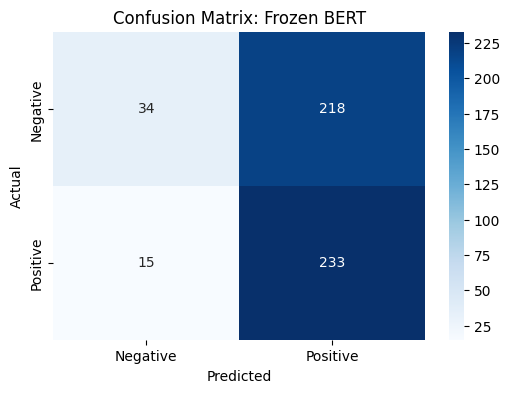

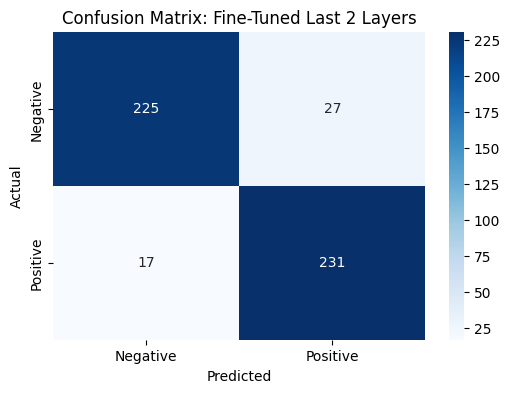

In [6]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Run Experiment 1
labels_exp1, preds_exp1=run_experiment("freeze_all")

# Run Experiment 2
labels_exp2, preds_exp2=run_experiment("fine_tune_last_2")

# Visualization Function
def plot_cm(y_true, y_pred, title):
    cm=confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.title(title)
    plt.show()

# Plot the confusion matrices side-by-side
plot_cm(labels_exp1, preds_exp1, "Confusion Matrix: Frozen BERT")
plot_cm(labels_exp2, preds_exp2, "Confusion Matrix: Fine-Tuned Last 2 Layers")